In [19]:
from matplotlib import pyplot as plt

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

import numpy as np

import pydicom as dicom

from datetime import datetime, timezone


1190 1190
SID:  999.977835626138


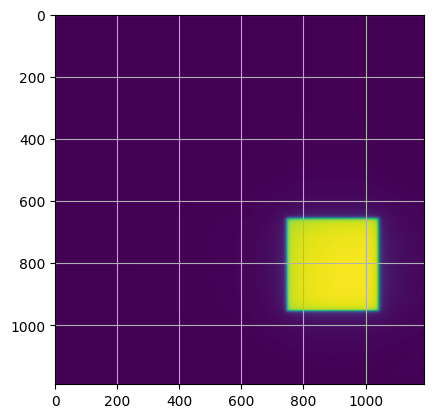

In [2]:
image_path = 'Solstice-m12_d18_2025-FS_EPID_Jaw OA 10x10.dcm'
#image_path = 'Solstice-m12_d18_2025-FS_EPID_Jaw 10x10.dcm'
#image_path = 'Solstice-m12_d18_2025-FS_EPID_MLC 10x38.dcm'
ds = dicom.dcmread(image_path)

print(ds.Rows, ds.Columns)
print("SID: ", ds.RTImageSID)

plt.grid(True)
plt.imshow(ds.pixel_array)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 190
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: RT Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.246.352.62.1.4933821198288747950.9223098124847698061
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.160.3
(0002, 0013) Implementation Version Name         SH: 'DCIE 2.2'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 192'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'PORTAL', 'ACQUIRED_DOSE']
(0008, 0012) Instance Creation Date              DA: '20251229'
(0008, 0013) Instance Creation Time              TM: '150309'
(0008, 0016) SOP Class UID                       UI: RT Image Storage
(0008, 0018

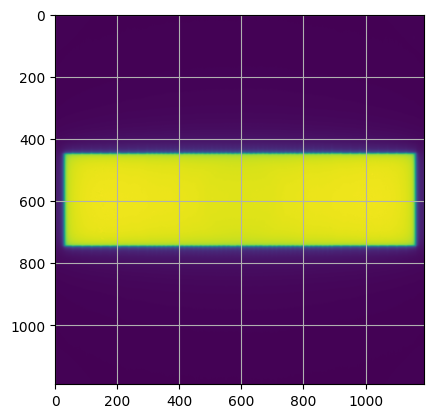

In [3]:
image_path = 'Solstice-m12_d18_2025-FS_EPID_MLC 10x38.dcm'
#image_path = 'Solstice-m12_d18_2025-FS_EPID_MLC 10x38.dcm'
ds = dicom.dcmread(image_path)

print(ds)
plt.grid(True)
plt.imshow(ds.pixel_array)


In [ ]:
def add_metadata(file_name):
    ds = dicom.dcmread(file_name)
    epoch = datetime(1970, 1, 1, tzinfo=timezone.utc)
    
    ds.InstanceCreationDate = datetime.now().strftime('%Y%m%d')
    ds.InstanceCreationTime = datetime.now().strftime('%H%M%S')
    ds.AcquisitionDate = datetime.now().strftime('%Y%m%d')
    ds.AcquisitionTime = datetime.now().strftime('%H%M%S')

    ds.StationName = 'TDCreator'
    ds.Manufacturer = 'TDCreator'
    ds.OperatorsName = 'TDCreator'

    ds.PatientBirthDate = epoch.strftime('%Y%m%d')
    ds.PatientBirthTime = epoch.strftime('%H%M%S')

    #TODO: Setup a way to dynamically pull software version
    ds.SoftwareVersions = '1.0'

    ds.PixelRepresentation = 0
    ds.PixelIntensityRelationship = 'LIN'
    ds.PixelIntensityRelationshipSign = 1

    ds.BeamLimitingDeviceAngle = 0.0
    ds.PatientSupportAngle = 0.0

    ds.TableTopVerticalPosition = 0.0
    ds.TableTopLongitudinalPosition = 20.0
    ds.TableTopLateralPosition = 0.0
    ds.TableTopPitchAngle = 0.0
    ds.TableTopRollAngle = 0.0

    exposure_dataset = dicom.Dataset()
    exposure_dataset.KVP = 6000.0
    exposure_dataset.ExposureTime = 1
    exposure_dataset.MetersetExposure = 100

    beam_limiting_device_dataset = dicom.Dataset()
    beam_limiting_device_dataset.LeafJawPositions = [-50.0, 50.0]
    exposure_dataset.GantryAngle = ds.GantryAngle
    exposure_dataset.TableTopVerticalPosition = ds.TableTopVerticalPosition
    exposure_dataset.TableTopLongitudinalPosition = ds.TableTopLongitudinalPosition
    exposure_dataset.TableTopLateralPosition = ds.TableTopLateralPosition
    exposure_dataset.TableTopPitchAngle = ds.TableTopPitchAngle
    exposure_dataset.TableTopRollAngle = ds.TableTopRollAngle
    exposure_dataset.BeamLimitingDeviceSequence = dicom.Sequence([beam_limiting_device_dataset])

    ds.ExposureSequence = dicom.Sequence([exposure_dataset])
    ds.IsocenterPosition = [0.0, 0.0, 0.0]

    print(ds)
    ds.save_as(file_name)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 246
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: RT Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.70636895888248008205464519676538144707
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.8.498.51351858128105644228406984717870474999
(0002, 0013) Implementation Version Name         SH: 'PYDICOM 2.4.5'
-------------------------------------------------
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OTHER']
(0008, 0012) Instance Creation Date              DA: '20260609'
(0008, 0013) Instance Creation Time              TM: '110645'
(0008, 0016) SOP Class UID                       UI: RT Image Storage
(0008, 0018) SOP Instance UID             

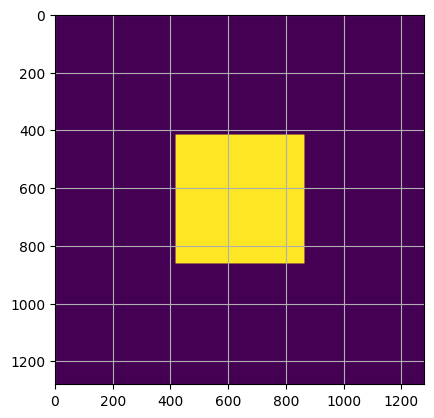

In [25]:
#image_path = 'lightrad.dcm'
image_path = 'EPID Perfect Open Field 10x10.dcm'

add_metadata(image_path)

ds = dicom.dcmread(image_path)



plt.grid(True)
plt.imshow(ds.pixel_array)
